In [4]:
# Import required libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set parameters
img_size = (224, 224)
batch_size = 32

# Load dataset
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    r'/Users/sagarkumarsahu/Desktop/project_exhibition2/archive/train', 
    target_size=img_size, batch_size=batch_size, class_mode='categorical')

test_generator = test_datagen.flow_from_directory(
    r'/Users/sagarkumarsahu/Desktop/project_exhibition2/archive/test', 
    target_size=img_size, batch_size=batch_size, class_mode='categorical')

# Load Pretrained EfficientNetB0 model
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze layers

# Add Custom Layers
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')  # train_generator is now defined
])

# Compile and Train
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_generator, validation_data=test_generator, epochs=5)

# Save model
model.save("efficientnetb0_model.h5")


Found 928 images belonging to 4 classes.
Found 448 images belonging to 4 classes.


/Users/sagarkumarsahu/Desktop/project_exhibition2/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 24s 708ms/step - accuracy: 0.2602 - loss: 1.4984 - val_accuracy: 0.2500 - val_loss: 1.3907
Epoch 2/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 648ms/step - accuracy: 0.2647 - loss: 1.4131 - val_accuracy: 0.2500 - val_loss: 1.3953
Epoch 3/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 731ms/step - accuracy: 0.3098 - loss: 1.3706 - val_accuracy: 0.2500 - val_loss: 1.3944
Epoch 4/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 719ms/step - accuracy: 0.2806 - loss: 1.3868 - val_accuracy: 0.2500 - val_loss: 1.3976
Epoch 5/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 728ms/step - accuracy: 0.2936 - loss: 1.3785 - val_accuracy: 0.2500 - val_loss: 1.3903


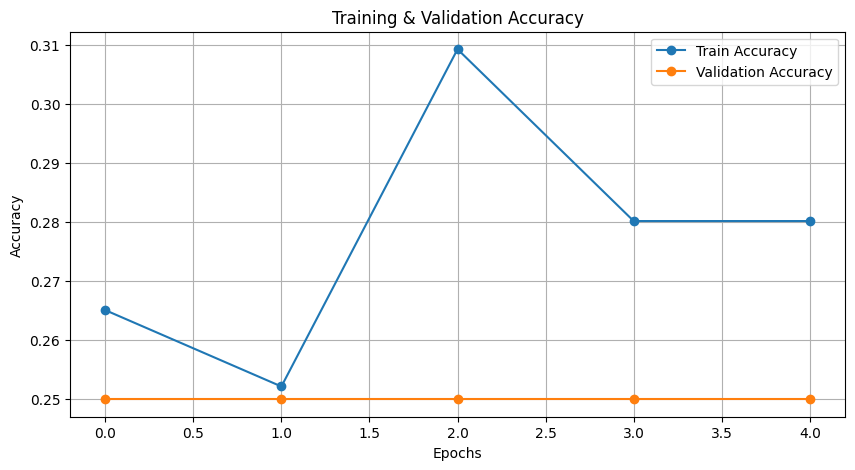

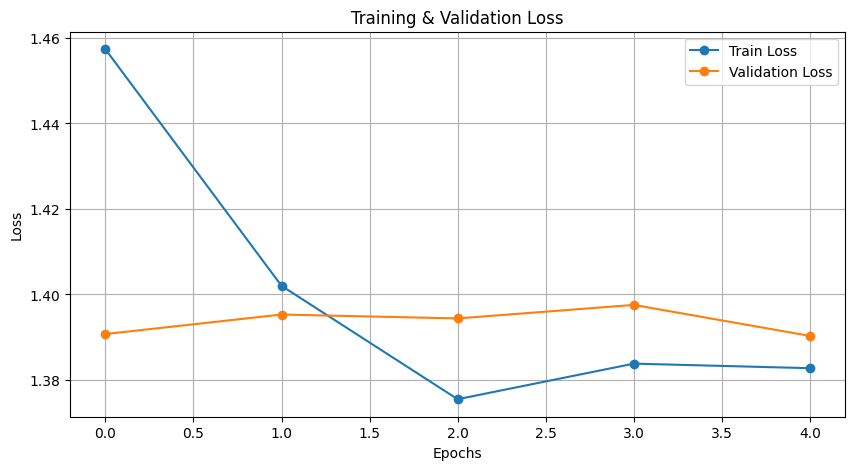

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
# Extract training history
history = model.history.history

# Plot Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()
plt.grid()
plt.show()

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(history['loss'], label='Train Loss', marker='o')
plt.plot(history['val_loss'], label='Validation Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid()
plt.show()


In [6]:
# Get true labels
true_labels = test_generator.classes

# Get class names
class_names = list(test_generator.class_indices.keys())

# Predict probabilities
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)


14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 426ms/step


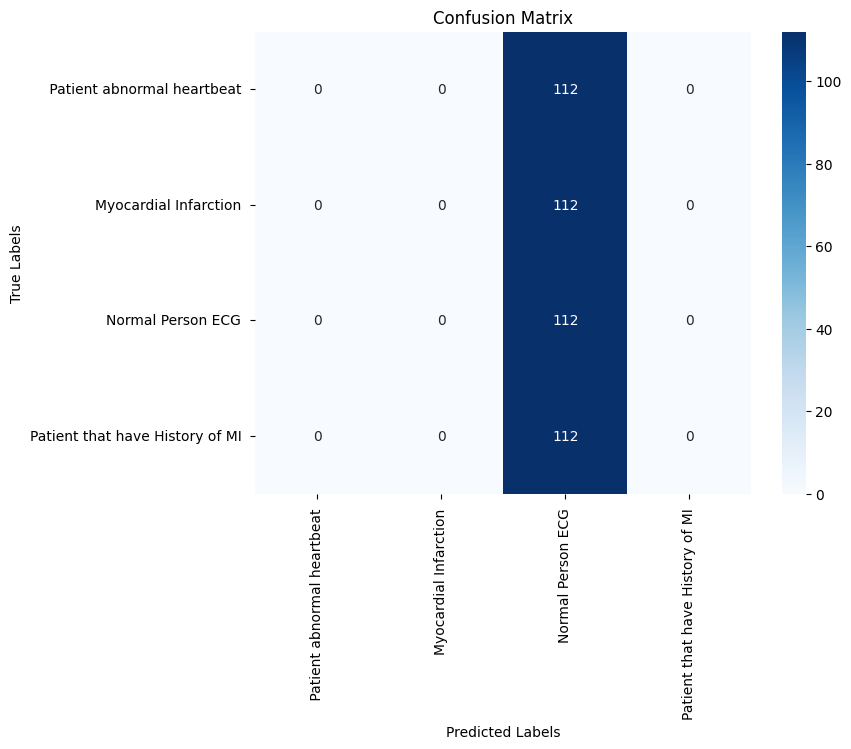

In [7]:
# Compute confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_classes)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


In [8]:
# Print classification report
report = classification_report(true_labels, predicted_classes, target_names=class_names)
print(report)


                                  precision    recall  f1-score   support

     Patient abnormal heartbeat        0.00      0.00      0.00       112
          Myocardial Infarction        0.00      0.00      0.00       112
              Normal Person ECG        0.25      1.00      0.40       112
Patient that have History of MI        0.00      0.00      0.00       112

                        accuracy                           0.25       448
                       macro avg       0.06      0.25      0.10       448
                    weighted avg       0.06      0.25      0.10       448



/Users/sagarkumarsahu/Desktop/project_exhibition2/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/sagarkumarsahu/Desktop/project_exhibition2/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/sagarkumarsahu/Desktop/project_exhibition2/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control th

In [9]:
# Compute accuracy and F1-score
accuracy = accuracy_score(true_labels, predicted_classes)
f1 = f1_score(true_labels, predicted_classes, average='weighted')

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Weighted F1 Score: {f1:.4f}")


Test Accuracy: 0.2500
Weighted F1 Score: 0.1000
